<a href="https://colab.research.google.com/github/sirsatshraddha12-bit/Python_libraries/blob/main/Datavisualization_MLbasics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

In [2]:
# Load Titanic dataset
df = sns.load_dataset('titanic')

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


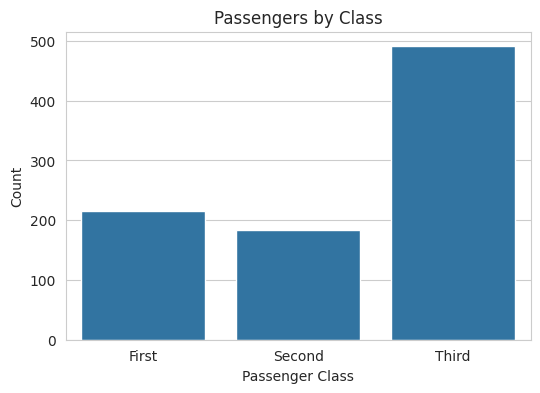

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x='class', data=df)

plt.title("Passengers by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_7113/2048355956.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare = df.groupby('class')['fare'].mean()


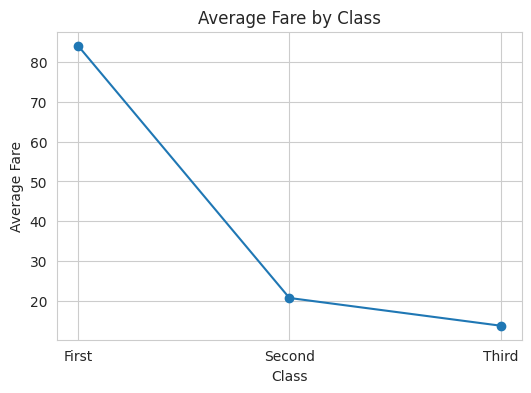

In [7]:
fare = df.groupby('class')['fare'].mean()

plt.figure(figsize=(6,4))

plt.plot(fare.index, fare.values, marker='o')

plt.title("Average Fare by Class")
plt.xlabel("Class")
plt.ylabel("Average Fare")

plt.show()

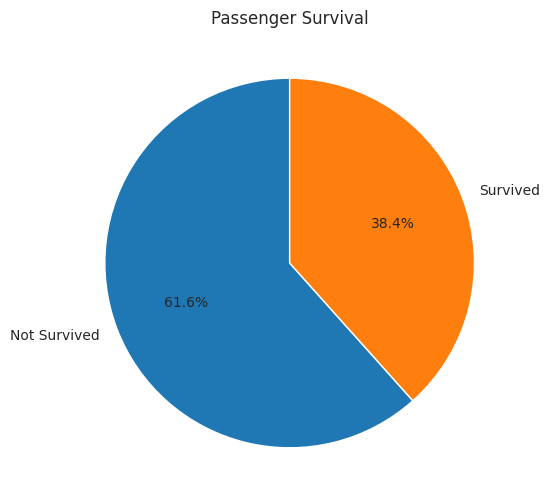

In [8]:
survival = df['survived'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(survival,
        labels=['Not Survived','Survived'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Passenger Survival")

plt.show()

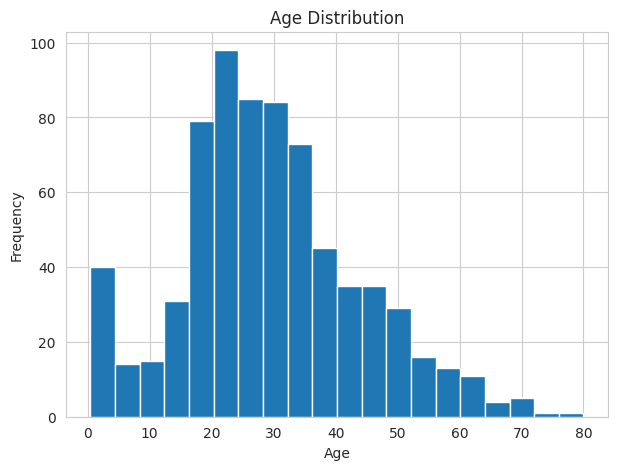

In [9]:
plt.figure(figsize=(7,5))

plt.hist(df['age'].dropna(), bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

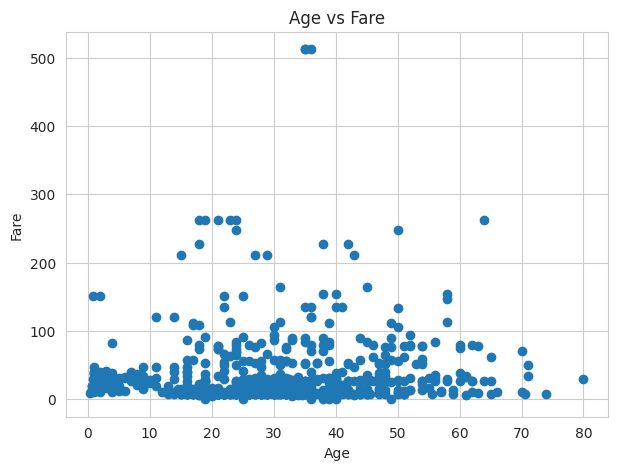

In [10]:
plt.figure(figsize=(7,5))

plt.scatter(df['age'], df['fare'])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

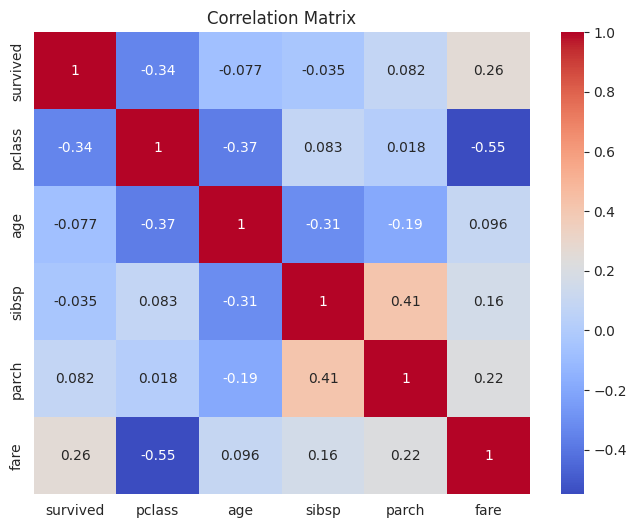

In [11]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

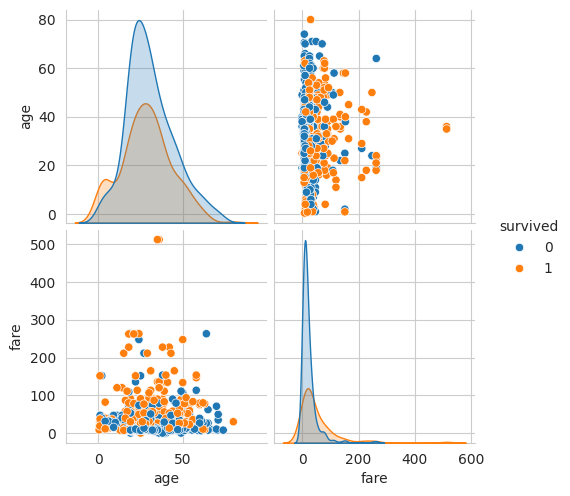

In [12]:
sns.pairplot(df[['age','fare','survived']].dropna(),
             hue='survived')

plt.show()

In [ ]:
Machine Learning Basics using Scikit-learn

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Regression
from sklearn.linear_model import LinearRegression

# Classification
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report

sns.set_style("whitegrid")

In [14]:
student_data = {
    "Hours":[1,2,3,4,5,6,7,8,9,10],
    "Score":[20,30,35,50,55,65,70,80,88,95]
}

df = pd.DataFrame(student_data)

df.head()

,Hours,Score
0,1,20
1,2,30
2,3,35
3,4,50
4,5,55


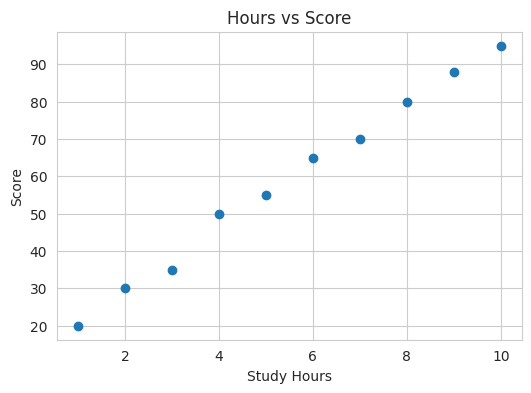

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(df["Hours"],df["Score"])
plt.title("Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

In [16]:
X = df[["Hours"]]
y = df["Score"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [17]:
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

print(y_pred)

[88.01724138 29.48275862]


In [19]:
print("MAE :",mean_absolute_error(y_test,y_pred))
print("MSE :",mean_squared_error(y_test,y_pred))
print("R2 Score :",r2_score(y_test,y_pred))

MAE : 0.26724137931034875
MSE : 0.13391795481569768
R2 Score : 0.9998407634306591


In [20]:
hours = [[7.5]]

prediction = model.predict(hours)

print("Predicted Score =",prediction[0])

Predicted Score = 75.47413793103448


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
house = {
    "Area":[600,800,1000,1200,1500,1800,2000,2200],
    "Price":[25,35,45,50,65,75,85,95]
}

house_df = pd.DataFrame(house)

house_df

,Area,Price
0,600,25
1,800,35
2,1000,45
3,1200,50
4,1500,65
5,1800,75
6,2000,85
7,2200,95


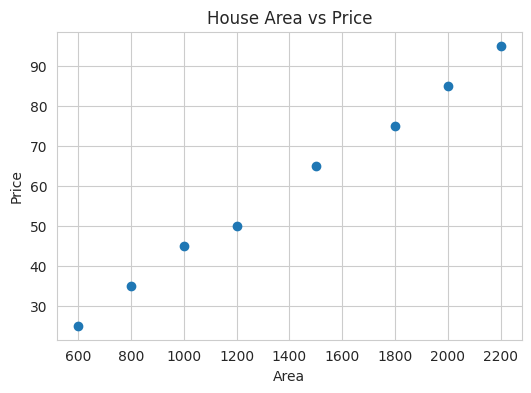

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(house_df["Area"],house_df["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Area vs Price")
plt.show()

In [23]:
X = house_df[["Area"]]

y = house_df["Price"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=0
)

In [24]:
house_model = LinearRegression()

house_model.fit(X_train,y_train)

LinearRegression()

In [25]:
pred = house_model.predict(X_test)

pred

array([85.39509537, 42.47956403])

In [26]:
print("MAE =",mean_absolute_error(y_test,pred))
print("R2 =",r2_score(y_test,pred))

MAE = 1.4577656675749289
R2 = 0.9918641277312921


In [27]:
new_house = [[1700]]

price = house_model.predict(new_house)

print("Predicted Price =",price[0],"Lakhs")

Predicted Price = 72.52043596730245 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [28]:
iris = load_iris()

X = iris.data

y = iris.target

In [29]:
print(iris.feature_names)

print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [30]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)

In [31]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=3)

classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [32]:
prediction = classifier.predict(X_test)

prediction

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

In [33]:
accuracy = accuracy_score(y_test,prediction)

print("Accuracy =",accuracy)

Accuracy = 1.0


In [34]:
cm = confusion_matrix(y_test,prediction)

print(cm)

[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


In [35]:
sample = [[5.1,3.5,1.4,0.2]]

flower = classifier.predict(sample)

print("Predicted Flower :",iris.target_names[flower][0])

Predicted Flower : setosa
